In [123]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing modules fro sklearn library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import r2_score

#Importing model from statmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

#Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [124]:
#Data sample
data = pd.read_csv('Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [125]:
#Data Volume
data.shape

(545, 13)

In [126]:
#Misssing values check
pd.DataFrame({'Missing Values' : round(data.isnull().mean(), 2), 'Data Types' : data.dtypes})

,Missing Values,Data Types
price,0.0,int64
area,0.0,int64
bedrooms,0.0,int64
bathrooms,0.0,int64
stories,0.0,int64
mainroad,0.0,object
guestroom,0.0,object
basement,0.0,object
hotwaterheating,0.0,object
airconditioning,0.0,object


In [127]:
# Duplicate check in row
if len(data[data.duplicated(keep=False)]) > 0:
    print('The data has duplicates')
elif len(data[data.duplicated(keep=False)]) == 0:
    print('The data has no row duplicates')    

The data has no row duplicates


In [128]:
# Duplicate check in column
if len(data.columns[data.T.duplicated(keep=False)]) > 0:
    print('The data has duplicates')
elif len(data.columns[data.T.duplicated(keep=False)]) == 0:
    print('The data has no column duplicates')    

The data has no column duplicates


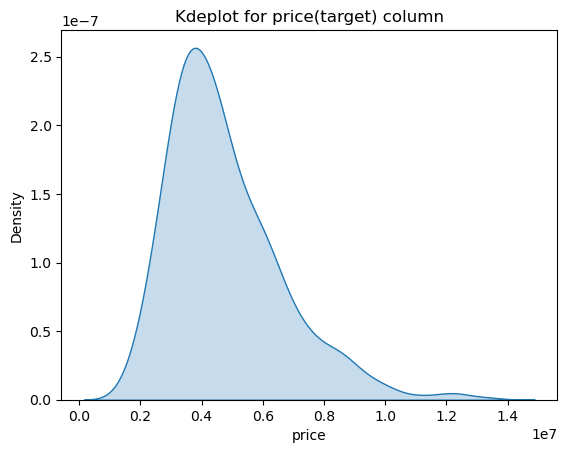

In [129]:
# Analyse the target column
sns.kdeplot(data = data, x=data['price'], fill=True)
plt.title('Kdeplot for price(target) column')
plt.show()

In [130]:
#Understanding the categorical columns
cat_cols = []
for cols in data.columns:
    if data[cols].dtypes == 'O':
        print(cols, ':', data[cols].unique())
        cat_cols.append(cols)

mainroad : ['yes' 'no']
guestroom : ['no' 'yes']
basement : ['no' 'yes']
hotwaterheating : ['no' 'yes']
airconditioning : ['yes' 'no']
prefarea : ['yes' 'no']
furnishingstatus : ['furnished' 'semi-furnished' 'unfurnished']


In [131]:
#Dependency split
x = data.iloc[:, 1:]
y = data[['price']]

#Train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

#Dimensions of train test split
print('Dimensions of train data:', x_train.shape, y_train.shape)
print('Dimensions of test data:', x_test.shape, y_test.shape)

Dimensions of train data: (436, 12) (436, 1)
Dimensions of test data: (109, 12) (109, 1)


In [132]:
#One Hot Encoding
encoder = OneHotEncoder(sparse_output = False, dtype = 'i1', drop = 'first')

#Training data
x_train_encoded = encoder.fit_transform(x_train[cat_cols])
x_train_encoded_df = pd.DataFrame(x_train_encoded, index = x_train.index, columns = encoder.get_feature_names_out())
x_train_encoded_df = pd.concat([x_train.drop(cat_cols, axis =1), x_train_encoded_df], axis = 1)


#Test data
x_test_encoded = encoder.fit_transform(x_test[cat_cols])
x_test_encoded_df = pd.DataFrame(x_test_encoded, index = x_test.index, columns = encoder.get_feature_names_out())
x_test_encoded_df = pd.concat([x_test.drop(cat_cols, axis =1), x_test_encoded_df], axis = 1)

In [133]:
#Data scaling for independent columns
scaler = MinMaxScaler()

#Train scaling
x_train_scaled = scaler.fit_transform(x_train_encoded_df)
x_train_scaled_df = pd.DataFrame(x_train_scaled, index = x_train_encoded_df.index, columns = scaler.get_feature_names_out())

#Test scaling
x_test_scaled = scaler.transform(x_test_encoded_df)
x_test_scaled_df = pd.DataFrame(x_test_scaled, index = x_test_encoded_df.index, columns = scaler.get_feature_names_out())

#Data scaling of the target
scaler_t = MinMaxScaler()
y_train_scaled = scaler_t.fit_transform(y_train)
y_test_scaled = scaler_t.transform(y_test)

# Model Building

In [134]:
#Train data sample
x_train_scaled_df.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,0.298969,0.4,0.333333,1.000000,0.333333,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
93,0.381443,0.4,0.333333,0.000000,1.000000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
335,0.148866,0.2,0.000000,0.000000,0.666667,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
412,0.065979,0.4,0.000000,0.333333,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
471,0.144330,0.4,0.000000,0.333333,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [135]:
#Simple linear model for area to predict price

#Add constant
lr_data = sm.add_constant(x_train_scaled_df['area'])

#Fit the data onto the ols model
lr_model = sm.OLS(y_train_scaled, lr_data).fit()

#Model params
print(round(lr_model.params, 4))

# price = 0.5899*(area) + 0.1395 (y = mx + c)

const    0.1395
area     0.5899
dtype: float64


In [136]:
lr_data

,const,area
46,1.0,0.298969
93,1.0,0.381443
335,1.0,0.148866
412,1.0,0.065979
471,1.0,0.144330
...,...,...
71,1.0,0.298969
106,1.0,0.261168
270,1.0,0.195876
435,1.0,0.164261


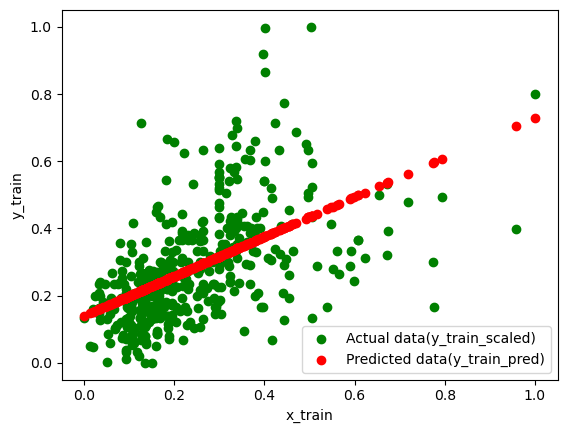

In [137]:
#Scatter plot
plt.scatter(x_train_scaled_df['area'], y_train_scaled, color='green', label='Actual data(y_train_scaled)')                                    #Raw data, that is actual data corresponding to x_train.
plt.scatter(x_train_scaled_df['area'], 0.5899*(x_train_scaled_df['area']) + 0.1395, color='red', label='Predicted data(y_train_pred)')      #Predicted data after model training and passing of x_train_scaled_df.
plt.xlabel('x_train')
plt.ylabel('y_train')
plt.legend()  # Add a legend to show what each color represents
plt.show()

In [138]:
#Residual analysis
y_train_pred = lr_model.predict(lr_data)
res = pd.Series(y_train_scaled.ravel(), index = x_train_scaled_df.index) - y_train_pred

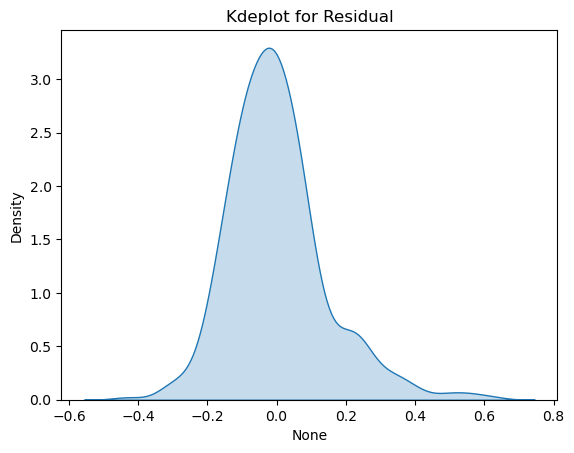

In [139]:
#Kde plot
sns.kdeplot(data = data, x=res, fill=True)
plt.title('Kdeplot for Residual')
plt.show()

In [140]:
#R-Squared
RSS = ((pd.Series(y_train_scaled.ravel(), index = x_train_scaled_df.index) - y_train_pred)**2).sum()
TSS = ((y_train_scaled - y_train_scaled.mean())**2).sum()
r_square = 1 - (RSS/TSS)
print(f'R-squared: {round((r_square)*100, 2)}%')

R-squared: 28.5%


In [141]:
#Model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     173.0
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           1.75e-33
Time:                        12:48:27   Log-Likelihood:                 234.19
No. Observations:                 436   AIC:                            -464.4
Df Residuals:                     434   BIC:                            -456.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1395      0.013     10.933      0.0

In [142]:
#Bilinear model for area to predict price

#Add constant
bi_lr_data = sm.add_constant(x_train_scaled_df[['area', 'bedrooms']])

#Fit the data onto the ols model
bi_lr_model = sm.OLS(y_train_scaled, bi_lr_data).fit()

#Model params
print(round(bi_lr_model.params, 4))

# price = 0.5899*(area) + 0.1395 (y = mx + c)

const       0.0219
area        0.5394
bedrooms    0.3313
dtype: float64


In [143]:
#Model summary
print(bi_lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     127.4
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           3.10e-44
Time:                        12:48:27   Log-Likelihood:                 261.94
No. Observations:                 436   AIC:                            -517.9
Df Residuals:                     433   BIC:                            -505.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0219      0.019      1.125      0.2

In [144]:
#Multilinear regression model for area to predict price

#Add constant
mlr_data = sm.add_constant(x_train_scaled_df)

#Fit the data onto the ols model
mlr_model = sm.OLS(y_train_scaled, mlr_data).fit()

#Model params
print(round(mlr_model.params, 4))

# price = 0.5899*(area) + 0.1395 (y = mx + c)

const                              0.0455
area                               0.3270
bedrooms                           0.0366
bathrooms                          0.3127
stories                            0.1164
parking                            0.0642
mainroad_yes                       0.0350
guestroom_yes                      0.0221
basement_yes                       0.0372
hotwaterheating_yes                0.0652
airconditioning_yes                0.0754
prefarea_yes                       0.0600
furnishingstatus_semi-furnished   -0.0121
furnishingstatus_unfurnished      -0.0394
dtype: float64


In [145]:
#Model summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     70.90
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           2.16e-97
Time:                        12:48:27   Log-Likelihood:                 413.55
No. Observations:                 436   AIC:                            -799.1
Df Residuals:                     422   BIC:                            -742.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

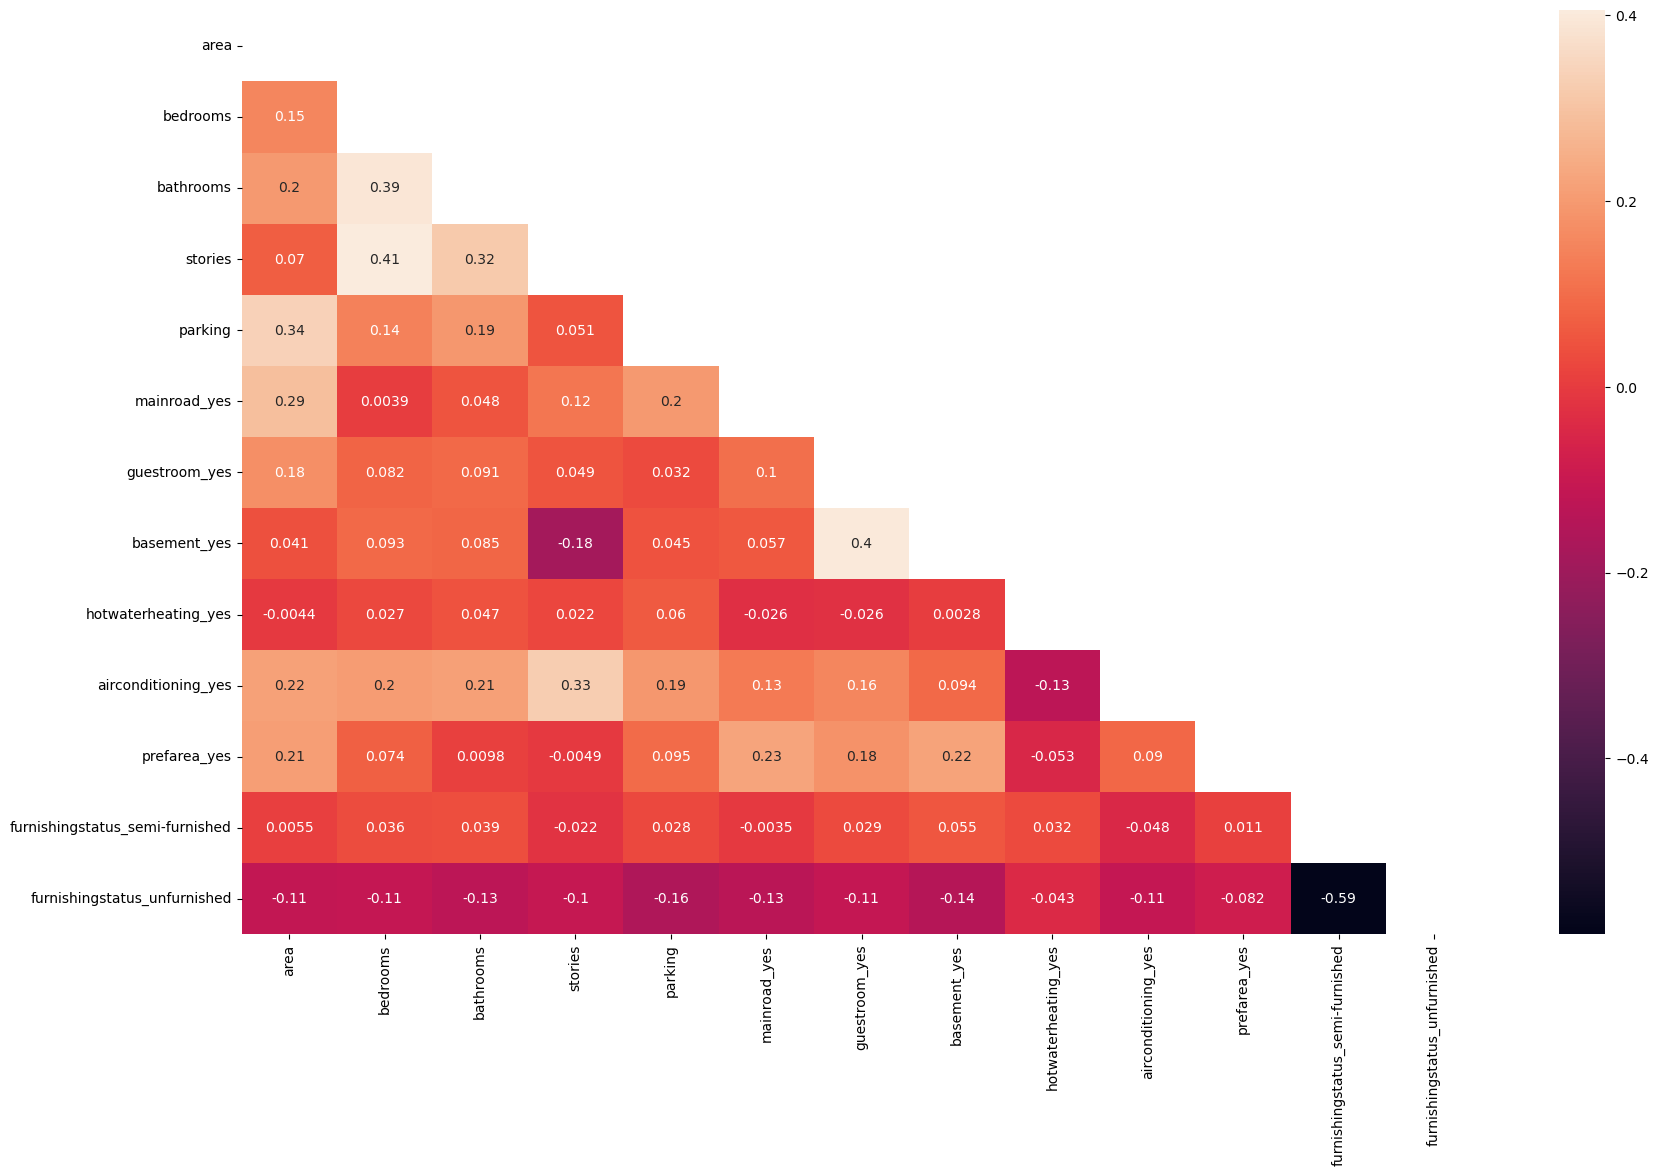

In [146]:
#Heatmap to check multicollinearity
plt.figure(figsize=(20, 12))
sns.heatmap(x_train_scaled_df.corr(), annot=True, mask=np.triu(x_train_scaled_df.corr()))
plt.show()

In [147]:
#Droping the 'semi-furnished' as the value of p>0.05
x_tr = x_train_scaled_df.drop(['furnishingstatus_semi-furnished'], axis = 1)

In [148]:
#Refitting the data

#Add constant 
mlr_data_2 = sm.add_constant(x_tr)

#Fit the data onto the OLS model
mlr_model_2 = sm.OLS(y_train_scaled, mlr_data_2).fit()

#Model summary
print(mlr_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     76.70
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           4.11e-98
Time:                        12:48:28   Log-Likelihood:                 412.99
No. Observations:                 436   AIC:                            -800.0
Df Residuals:                     423   BIC:                            -747.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [149]:
#Droping the 'guestroom_yes' as the value of p>0.05
x_tr = x_tr.drop(['guestroom_yes'], axis = 1)

In [150]:
#Refitting the data

#Add constant 
mlr_data_3 = sm.add_constant(x_tr)

#Fit the data onto the OLS model
mlr_model_3 = sm.OLS(y_train_scaled, mlr_data_3).fit()

#Model summary
print(mlr_model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     83.09
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           1.68e-98
Time:                        12:48:28   Log-Likelihood:                 411.60
No. Observations:                 436   AIC:                            -799.2
Df Residuals:                     424   BIC:                            -750.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [151]:
#Dataframe with column name and respective vif
vif_df = pd.DataFrame()
vif_df['Fetaure'] = x_tr.columns
vif_df['VIF'] = [round(vif(x_tr.values, i), 2) for i in range(x_tr.shape[1])]
vif_df.sort_values(by = 'VIF', ascending = False, inplace = True)
vif_df

,Fetaure,VIF
1,bedrooms,6.80
5,mainroad_yes,5.64
0,area,4.41
3,stories,2.74
4,parking,1.98
6,basement_yes,1.81
8,airconditioning_yes,1.81
2,bathrooms,1.66
9,prefarea_yes,1.48
10,furnishingstatus_unfurnished,1.41


In [152]:
#Droping the bedroom based on vif
x_tr = x_tr.drop(['bedrooms'], axis = 1)

In [153]:
#Refitting the data

#Add constant
mlr_data_4 = sm.add_constant(x_tr)

#Fit the data onto the OLS model
mlr_model_4 = sm.OLS(y_train_scaled, mlr_data_4).fit()

#Model summary
print(mlr_model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     91.34
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           2.66e-99
Time:                        12:48:28   Log-Likelihood:                 411.14
No. Observations:                 436   AIC:                            -800.3
Df Residuals:                     425   BIC:                            -755.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [154]:
#Dataframe with column name and respective vif
vif_df = pd.DataFrame()
vif_df['Feature'] = x_tr.columns
vif_df['VIF'] = [round(vif(x_tr.values, i), 2) for i in range(x_tr.shape[1])]
vif_df.sort_values(by = 'VIF', ascending = False, inplace = True)
vif_df

,Feature,VIF
4,mainroad_yes,4.91
0,area,4.17
2,stories,2.29
3,parking,1.97
7,airconditioning_yes,1.81
5,basement_yes,1.67
1,bathrooms,1.59
8,prefarea_yes,1.48
9,furnishingstatus_unfurnished,1.32
6,hotwaterheating_yes,1.08


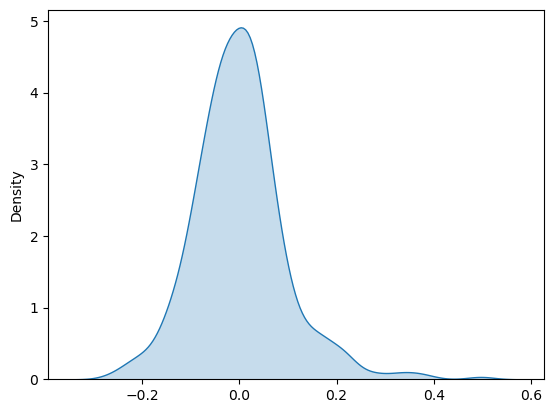

In [155]:
#Residual analysis
y_train_pred = mlr_model_4.predict(mlr_data_4)
res = pd.Series(y_train_scaled.ravel(), index = x_train_scaled_df.index) - y_train_pred

#Kde plot for res of final model
sns.kdeplot(res, fill = True)
plt.show()

In [156]:
#Test prediction

#Add constant
x_test_m4_data = sm.add_constant(x_test_scaled_df)

#Drop the data that are removed in training
x_test_m4_data.drop(['furnishingstatus_semi-furnished', 'guestroom_yes', 'bedrooms'], axis=1, inplace=True)

#Prediction on the data
y_pred_m4_data = mlr_model_4.predict(x_test_m4_data)

In [157]:
#Model accuracy
print('Testing accuracy:', round(r2_score(y_test_scaled, y_pred_m4_data)*100, 2), '%')

Testing accuracy: 64.8 %
